# Research Paper Categorization: A Complete ML Story

## The Question
**Given only the title and abstract of a research paper, can a machine learn to categorize it?**

This notebook tells a story: We have thousands of research papers labeled as **Theory**, **Survey**, or **Applied**. Can we build a classifier that learns to predict the category automatically? 

### Why This Matters
- **Academic search engines** tag papers automatically
- **Recommendation systems** categorize content for relevance
- **Automated tagging** saves time for researchers
- We're solving a **realistic, practical problem** with text—the hardest part of ML

---

## Pipeline Overview

Our journey:
1. **Load & explore** the data
2. **Preprocess** text (clean, normalize, tokenize)
3. **Vectorize** with TF-IDF (text → numbers)
4. **Build a classifier from scratch** (multinomial logistic regression)
5. **Train** with gradient descent
6. **Evaluate** thoroughly (confusion matrix, metrics, confidence, misclassifications)
7. **Demo** on a new paper

Let's begin!

In [1]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)
sns.set_theme(style='whitegrid')


## Step 1: Load Dataset and Inspect Structure

Required columns: `title`, `abstract`, `label`.

In [2]:
df = pd.read_csv('data/combined_papers_cleaned.csv')

print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Labels: {df['label'].unique().tolist()}")
print(f"Missing values:\n{df.isnull().sum()}")


Dataset shape: (2855, 19)
Columns: ['label', 'title', 'abstract', 'arxiv_id', 'primary_category', 'categories', 'published', 'arxiv_url', 'topic', 'list_name', 'found_in_arxiv_api', 'source_dataset', 'model_text', 'title_norm', 'abstract_norm', 'text_fingerprint', 'title_length', 'abstract_length', 'published_year']
Labels: ['APPLIED', 'THEORETICAL', 'SURVEY']
Missing values:
label                    0
title                    0
abstract                 0
arxiv_id                 0
primary_category         0
categories               0
published                0
arxiv_url                0
topic                 1996
list_name             1996
found_in_arxiv_api    1996
source_dataset           0
model_text               0
title_norm               0
abstract_norm            0
text_fingerprint         0
title_length             0
abstract_length          0
published_year           0
dtype: int64


In [3]:
sample_table = (
    df[['label', 'title']]
    .groupby('label', as_index=False)
    .head(1)
    .rename(columns={'label': 'category'})
)
display(sample_table)


,category,title
0,APPLIED,Towards Generalizable Robotic Manipulation in ...
998,THEORETICAL,Smaller Depth-2 Linear Circuits for Disjointne...
1996,SURVEY,A Comprehensive Survey on Community Detection ...


## Step 2: Class Distribution Visualization

Check imbalance before modeling.

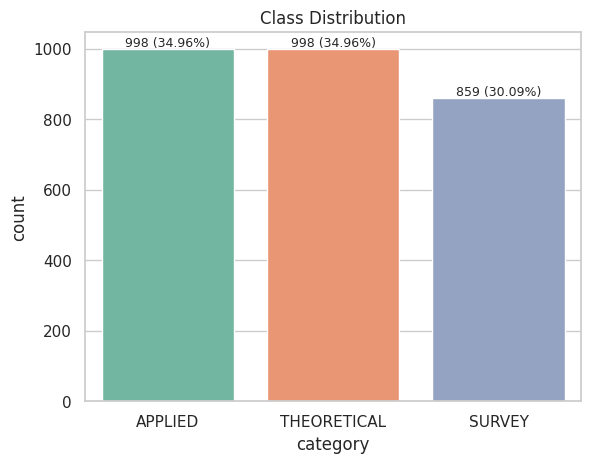

In [4]:
counts = df['label'].value_counts()
perc = (counts / counts.sum() * 100).round(2)
plot_df = pd.DataFrame({'category': counts.index, 'count': counts.values, 'pct': perc.values})

a = sns.barplot(data=plot_df, x='category', y='count', hue='category', palette='Set2', legend=False)
for i, r in plot_df.reset_index(drop=True).iterrows():
    a.text(i, r['count'], f"{int(r['count'])} ({r['pct']}%)", ha='center', va='bottom', fontsize=9)
plt.title('Class Distribution')
plt.show()


## Step 3: Text Preprocessing Pipeline (Conceptual)

We show one abstract through: raw -> lower -> stopword-removed -> stemmed.

This section is a conceptual illustration so you can see what common NLP preprocessing does.

In [5]:
stop_words = set(ENGLISH_STOP_WORDS)

def tokens(t):
    return re.findall(r'[a-z]+', str(t).lower())

def remove_stop(t):
    return ' '.join([w for w in tokens(t) if w not in stop_words])

def light_stem_word(w):
    for suf in ('ing', 'ed', 'ly', 'ies', 's'):
        if w.endswith(suf) and len(w) > len(suf) + 2:
            return (w[:-3] + 'y') if suf == 'ies' else w[:-len(suf)]
    return w

def light_stem(t):
    return ' '.join(light_stem_word(w) for w in tokens(t))

raw = df.iloc[0]['abstract']
lower = raw.lower()
no_stop = remove_stop(raw)
stemmed = light_stem(no_stop)

display(pd.DataFrame({
    'stage': ['raw', 'lowercased', 'stopwords_removed', 'lightly_stemmed'],
    'text': [raw, lower, no_stop, stemmed]
}))


,stage,text
0,raw,Vision-Language-Action (VLA) models excel in s...
1,lowercased,vision-language-action (vla) models excel in s...
2,stopwords_removed,vision language action vla models excel static...
3,lightly_stemmed,vision language action vla model excel static ...


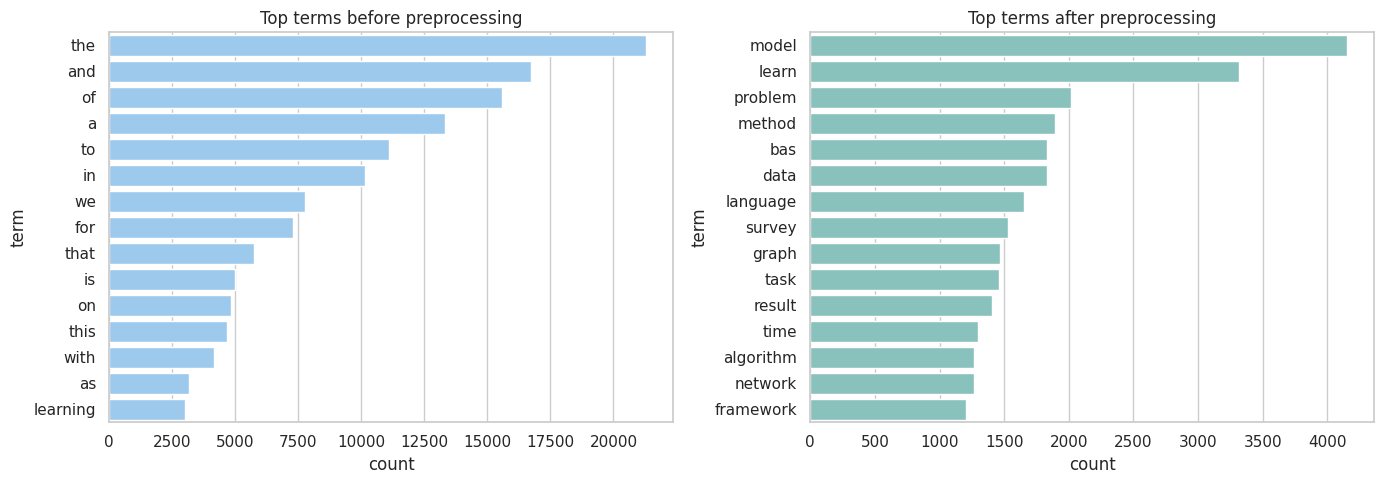

In [6]:
def top_terms(series, n=15):
    c = Counter()
    for t in series:
        c.update(tokens(t))
    return pd.DataFrame(c.most_common(n), columns=['term', 'count'])

before = top_terms(df['title'] + ' ' + df['abstract'])
after = top_terms((df['title'] + ' ' + df['abstract']).map(remove_stop).map(light_stem))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=before, x='count', y='term', ax=ax[0], color='#90caf9')
ax[0].set_title('Top terms before preprocessing')
sns.barplot(data=after, x='count', y='term', ax=ax[1], color='#80cbc4')
ax[1].set_title('Top terms after preprocessing')
plt.tight_layout(); plt.show()


## Step 4: Combine Title and Abstract into One Feature

Title is short and high-signal; abstract adds context.

In [7]:
df['combined_text'] = (df['title'].fillna('') + ' ' + df['abstract'].fillna('')).str.strip()

print('Combined text shape:', df['combined_text'].shape)

Combined text shape: (2855,)


## Step 5: TF-IDF Intuition with Toy Sentences

**TF-IDF** (Term Frequency–Inverse Document Frequency) converts text to numbers by weighing term importance:

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

Where:
- **TF** (Term Frequency): How many times term $t$ appears in document $d$
- **IDF** (Inverse Document Frequency): $\log\left(\frac{N}{n_t}\right)$, where $N$ is total docs and $n_t$ is docs containing term $t$

High TF-IDF means the term is frequent in this doc but rare overall (discriminative).

In [8]:
toy_docs = [
    'graph neural networks for molecules',
    'neural networks for image classification',
    'bayesian inference for scientific models'
]
toy_vec = TfidfVectorizer()
toy_X = toy_vec.fit_transform(toy_docs)
display(pd.DataFrame(toy_X.toarray(), columns=toy_vec.get_feature_names_out()))


,bayesian,classification,for,graph,image,inference,models,molecules,networks,neural,scientific
0,0.000000,0.000000,0.315444,0.534093,0.000000,0.000000,0.000000,0.534093,0.406192,0.406192,0.000000
1,0.000000,0.534093,0.315444,0.000000,0.534093,0.000000,0.000000,0.000000,0.406192,0.406192,0.000000
2,0.479528,0.000000,0.283217,0.000000,0.000000,0.479528,0.479528,0.000000,0.000000,0.000000,0.479528


## Step 6: Train/Validation/Test Split and Fit TF-IDF (No Leakage)

Split raw text first, then fit TF-IDF only on the training subset.

Note on preprocessing for this modeling step:

In [9]:
# Encode labels first so stratified splits are stable and reproducible.
lab2i = {l: i for i, l in enumerate(sorted(df['label'].unique()))}
i2lab = {i: l for l, i in lab2i.items()}
label_names = sorted(df['label'].unique())

y = df['label'].map(lab2i).values
X_text = df['combined_text'].values

# Split numerically: train 70% of (70% train + 20% val + 10% test unique shard)
idx_trainval, idx_test, X_trainval_text, X_test_text, y_trainval, y_test = train_test_split(
    np.arange(len(y)), X_text, y,
    test_size=0.1, random_state=42, stratify=y
)

X_train_text, X_val_text, y_train, y_val, idx_train, idx_val = train_test_split(
    X_trainval_text, y_trainval, idx_trainval,
    test_size=0.2, random_state=42, stratify=y_trainval
)

vectorizer = TfidfVectorizer(stop_words='english', max_features=12000, min_df=3, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(X_train_text)
X_val = vectorizer.transform(X_val_text)
X_test = vectorizer.transform(X_test_text)

feature_names = np.array(vectorizer.get_feature_names_out())
dfreq = np.asarray((X_train > 0).sum(axis=0)).ravel()

print('Train TF-IDF shape:', X_train.shape)
print('Validation TF-IDF shape:', X_val.shape)
print('Test TF-IDF shape:', X_test.shape)
print('Vocabulary size (fit on train only):', len(feature_names))

most_idx = np.argsort(-dfreq)[:20]
least_idx = np.argsort(dfreq)[:20]
display(pd.DataFrame({'term': feature_names[most_idx], 'train_doc_freq': dfreq[most_idx]}))
display(pd.DataFrame({'term': feature_names[least_idx], 'train_doc_freq': dfreq[least_idx]}))

Train TF-IDF shape: (2055, 12000)
Validation TF-IDF shape: (514, 12000)
Test TF-IDF shape: (286, 12000)
Vocabulary size (fit on train only): 12000


,term,train_doc_freq
0,based,802
1,models,791
2,learning,713
3,model,697
4,methods,620
5,data,602
6,paper,577
7,framework,568
8,results,538
9,survey,533


,term,train_doc_freq
0,164,3
1,120b,3
2,01,3
3,1981,3
4,1990,3
5,1993,3
6,1995,3
7,1996,3
8,different state,3
9,different techniques,3


## Step 6.2: TF-IDF Matrix Sparsity and Hyperparameter Effects

Train TF-IDF sparsity ratio: 0.9918


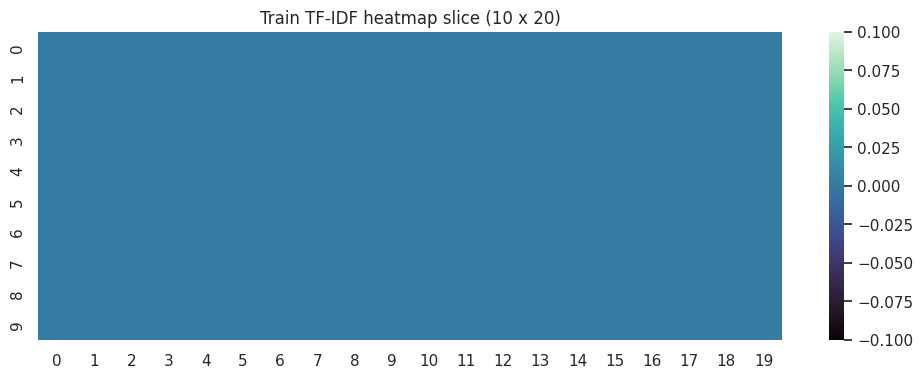

In [10]:
sparsity = 1.0 - (X_train.nnz / (X_train.shape[0] * X_train.shape[1]))
print('Train TF-IDF sparsity ratio:', round(sparsity, 4))

slice_mat = X_train[:10, :20].toarray()
plt.figure(figsize=(12, 4))
sns.heatmap(slice_mat, cmap='mako')
plt.title('Train TF-IDF heatmap slice (10 x 20)')
plt.show()

uni = TfidfVectorizer(stop_words='english', max_features=12000, min_df=3, ngram_range=(1,1)).fit(X_train_text)

## Step 7: Implement Softmax and Cross-Entropy

Before training, we need two core ideas:

**Softmax** converts logits to probabilities:
$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

**Cross-Entropy Loss** measures prediction error:
$$\mathcal{L}(y, \hat{p}) = -\frac{1}{N}\sum_{i=1}^{N} \sum_{k=1}^{K} y_{i,k} \log(\hat{p}_{i,k})$$

Where $y$ is one-hot true labels and $\hat{p}$ is predicted probability.

In [11]:
def softmax(logits):
    z = logits - np.max(logits, axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def cross_entropy(y_onehot, p, eps=1e-12):
    p = np.clip(p, eps, 1-eps)
    return -np.mean(np.sum(y_onehot * np.log(p), axis=1))

## Step 8: Logistic Regression Training Loop

Split and vectorization are already done above to prevent leakage.

In [12]:
# Cell A: prepare encoded labels/splits for training. Convert to dense and one-hot encode.
k = len(label_names)

Xtr = X_train.toarray()
Xva = X_val.toarray()
Xte = X_test.toarray()

Ytr = np.eye(k)[y_train]
Yva = np.eye(k)[y_val]

print(f"Training matrix shape: {Xtr.shape}")
print(f"One-hot labels shape: {Ytr.shape}")

Training matrix shape: (2055, 12000)
One-hot labels shape: (2055, 3)


### Step 8.3: Initialize Model Parameters ($W$ and $b$)

In [13]:
k = len(label_names)

W = np.random.normal(loc=0, scale=0.01, size=(Xtr.shape[1], k))
b = np.zeros((1, k))

print('W shape:', W.shape)
print('b shape:', b.shape)

W shape: (12000, 3)
b shape: (1, 3)


In [14]:
# Hyperparameter controls (edit and re-run this cell before training)
train_cfg = {
    'epochs': 500,
    'learning_rate': 0.5,
    'l2': 1e-4,
    'print_every': 20
}

### Step 8.4: Run Gradient Descent Training

In [15]:
# Read hyperparameters from the separate control cell.
default_cfg = {'epochs': 100, 'learning_rate': 0.5, 'l2': 1e-4, 'print_every': 20}

cfg = train_cfg if 'train_cfg' in globals() else default_cfg

epochs = int(cfg.get('epochs', default_cfg['epochs']))
lr = float(cfg.get('learning_rate', default_cfg['learning_rate']))
l2 = float(cfg.get('l2', default_cfg['l2']))
print_every = max(1, int(cfg.get('print_every', default_cfg['print_every'])))

hist = {'loss': [], 'train_acc': [], 'val_acc': []}
progress_rows = []

print(f"\nTraining start | epochs={epochs}, lr={lr}, l2={l2}, print_every={print_every}")
for ep in range(epochs):
    logits = Xtr @ W + b
    p = softmax(logits)
    loss = cross_entropy(Ytr, p) + 0.5 * l2 * np.sum(W * W)

    dlog = (p - Ytr) / len(y_train)
    dW = Xtr.T @ dlog + l2 * W
    db = dlog.sum(axis=0, keepdims=True)

    W -= lr * dW
    b -= lr * db

    tr_pred = p.argmax(axis=1)
    tr_acc = accuracy_score(y_train, tr_pred)
    
    # Validation accuracy
    val_logits = Xva @ W + b
    val_p = softmax(val_logits)
    val_pred = val_p.argmax(axis=1)
    val_acc = accuracy_score(y_val, val_pred)
    
    # Record metrics
    hist['loss'].append(loss)
    hist['train_acc'].append(tr_acc)
    hist['val_acc'].append(val_acc)
    
    # Print progress periodically
    if (ep + 1) % print_every == 0:
        print(f"Epoch {ep+1:3d}/{epochs} | Loss: {loss:.4f} | Train Acc: {tr_acc:.4f} | Val Acc: {val_acc:.4f}")

print("\nTraining complete!")
print(f"Final train accuracy: {hist['train_acc'][-1]:.4f}")
print(f"Final val accuracy: {hist['val_acc'][-1]:.4f}")


Training start | epochs=500, lr=0.5, l2=0.0001, print_every=20
Epoch  20/500 | Loss: 1.0560 | Train Acc: 0.6793 | Val Acc: 0.6790
Epoch  40/500 | Loss: 1.0147 | Train Acc: 0.7912 | Val Acc: 0.8249
Epoch  60/500 | Loss: 0.9760 | Train Acc: 0.8710 | Val Acc: 0.8930
Epoch  80/500 | Loss: 0.9396 | Train Acc: 0.9105 | Val Acc: 0.9280
Epoch 100/500 | Loss: 0.9054 | Train Acc: 0.9304 | Val Acc: 0.9397
Epoch 120/500 | Loss: 0.8734 | Train Acc: 0.9392 | Val Acc: 0.9514
Epoch 140/500 | Loss: 0.8433 | Train Acc: 0.9455 | Val Acc: 0.9591
Epoch 160/500 | Loss: 0.8151 | Train Acc: 0.9489 | Val Acc: 0.9630
Epoch 180/500 | Loss: 0.7887 | Train Acc: 0.9523 | Val Acc: 0.9650
Epoch 200/500 | Loss: 0.7638 | Train Acc: 0.9533 | Val Acc: 0.9630
Epoch 220/500 | Loss: 0.7404 | Train Acc: 0.9572 | Val Acc: 0.9630
Epoch 240/500 | Loss: 0.7185 | Train Acc: 0.9586 | Val Acc: 0.9669
Epoch 260/500 | Loss: 0.6978 | Train Acc: 0.9586 | Val Acc: 0.9669
Epoch 280/500 | Loss: 0.6783 | Train Acc: 0.9591 | Val Acc: 0.965

## Step 9: Track Training Curves

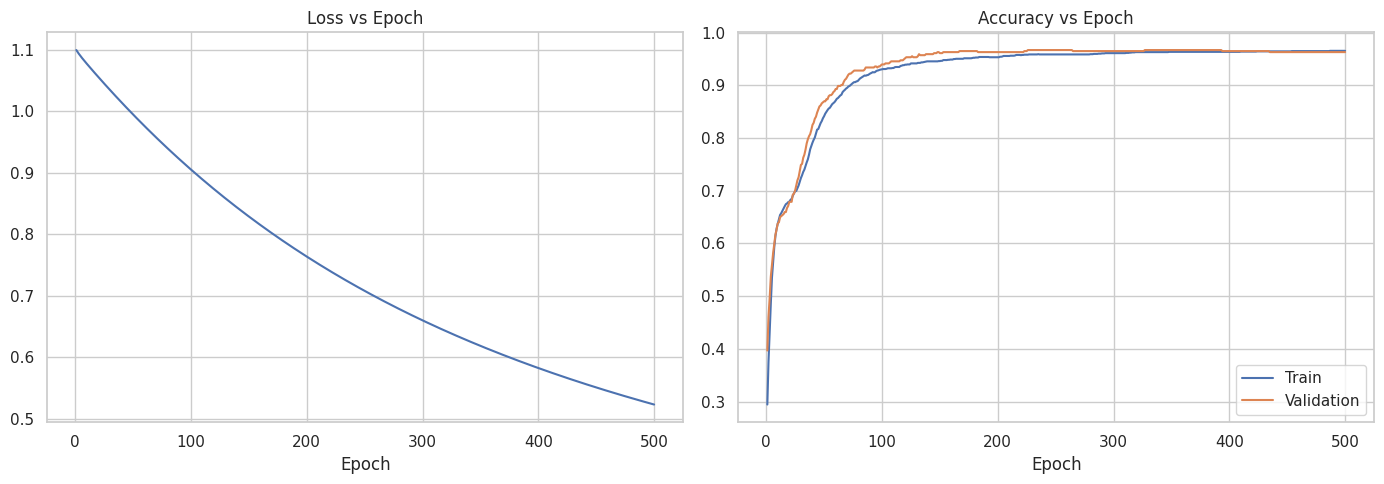

In [16]:
e = np.arange(1, len(hist['loss']) + 1)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(e, hist['loss'])
ax[0].set_title('Loss vs Epoch')
ax[0].set_xlabel('Epoch')

ax[1].plot(e, hist['train_acc'], label='Train')
ax[1].plot(e, hist['val_acc'], label='Validation')
ax[1].set_title('Accuracy vs Epoch')
ax[1].set_xlabel('Epoch')
ax[1].legend()

plt.tight_layout()
plt.show()

## Step 10: Inspect Top Weighted Terms per Class

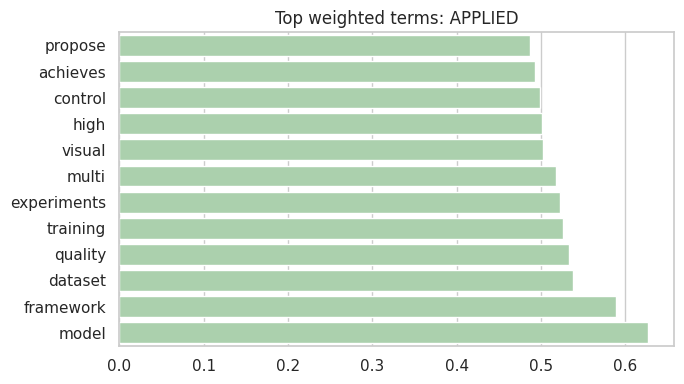

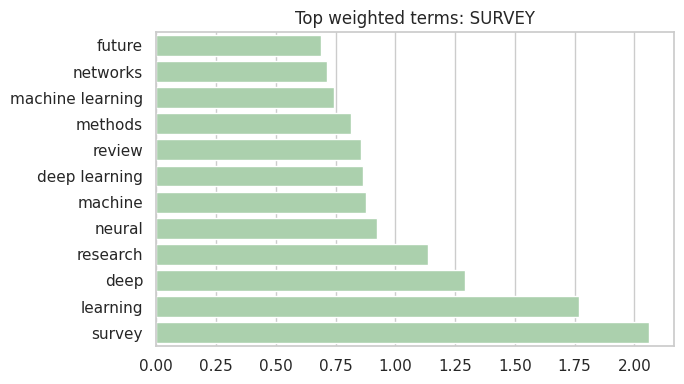

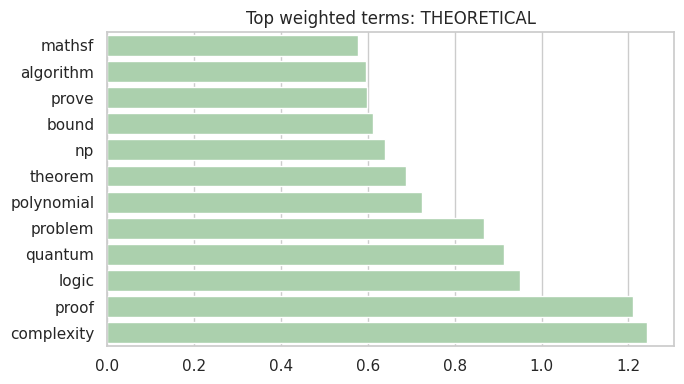

In [17]:
fn = np.array(vectorizer.get_feature_names_out())
for cidx, cname in i2lab.items():
    top = np.argsort(W[:, cidx])[-12:]
    terms = fn[top]
    vals = W[top, cidx]
    plt.figure(figsize=(7,4))
    sns.barplot(x=vals, y=terms, orient='h', color='#a5d6a7')
    plt.title(f'Top weighted terms: {cname}')
    plt.tight_layout(); plt.show()

## Step 11: Final Test-Set Evaluation Metrics

These metrics are computed only once after training completes.

Overall accuracy: 0.9545


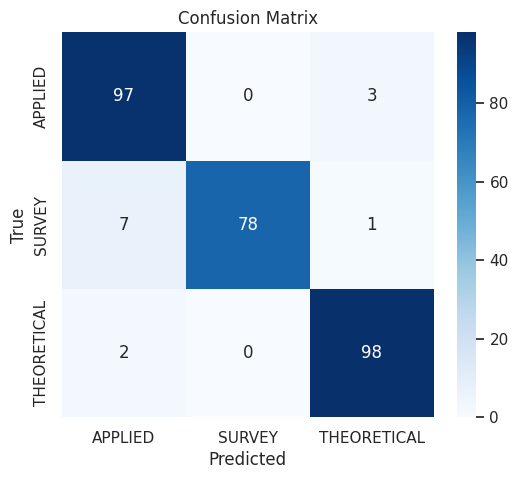

,precision,recall,f1-score,support
APPLIED,0.915094,0.970000,0.941748,100.000000
SURVEY,1.000000,0.906977,0.951220,86.000000
THEORETICAL,0.960784,0.980000,0.970297,100.000000
accuracy,0.954545,0.954545,0.954545,0.954545
macro avg,0.958626,0.952326,0.954421,286.000000
weighted avg,0.956601,0.954545,0.954578,286.000000


In [18]:
probs = softmax(Xte @ W + b)
y_pred = probs.argmax(axis=1)
acc = accuracy_score(y_test, y_pred)
print('Overall accuracy:', round(acc, 4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix'); plt.show()

rep = classification_report(y_test, y_pred, target_names=label_names, output_dict=True)
display(pd.DataFrame(rep).T)

## Step 12: Confidence Distribution and Calibration Check

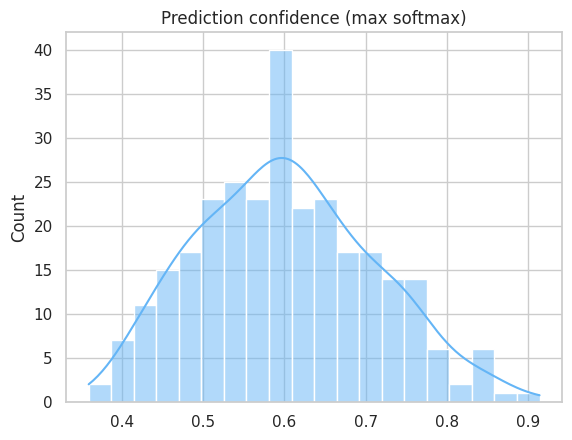

/tmp/ipykernel_167089/3048315721.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(grp.groupby('bucket').agg(count=('correct','size'), accuracy=('correct','mean')).reset_index())


,bucket,count,accuracy
0,"(-0.001, 0.4]",2,0.500000
1,"(0.4, 0.6]",140,0.914286
2,"(0.6, 0.8]",134,1.000000
3,"(0.8, 1.0]",10,1.000000


In [19]:
conf = probs.max(axis=1)
correct = (y_pred == y_test)

sns.histplot(conf, bins=20, kde=True, color='#64b5f6')
plt.title('Prediction confidence (max softmax)')
plt.show()

grp = pd.DataFrame({'confidence': conf, 'correct': correct})
grp['bucket'] = pd.cut(grp['confidence'], bins=[0,0.4,0.6,0.8,1.0], include_lowest=True)
display(grp.groupby('bucket').agg(count=('correct','size'), accuracy=('correct','mean')).reset_index())

## Step 13: Misclassification Review with Real Examples

In [20]:
err = np.where(y_pred != y_test)[0][:5]
for gi in err:
    pred_label = label_names[y_pred[gi]]
    true_label = label_names[y_test[gi]]
    conf_pct = 100.0 * probs[gi, y_pred[gi]]
    
    print(f"\n{'='*50}")
    print(f"| Predicted: {pred_label:10} (prob={conf_pct:.1f}%)")
    print(f"| Actual: {true_label:16}")
    print(f"{'='*50}")
    print(f"TITLE:\n{X_test_text[gi][:300]}")
    print()



| Predicted: APPLIED    (prob=46.7%)
| Actual: SURVEY          
TITLE:
A Survey on Visual Map Localization Using LiDARs and Cameras As the autonomous driving industry is slowly maturing, visual map localization is quickly becoming the standard approach to localize cars as accurately as possible. Owing to the rich data returned by visual sensors such as cameras or LiDAR


| Predicted: APPLIED    (prob=46.4%)
| Actual: SURVEY          
TITLE:
Prediction of neonatal mortality in Sub-Saharan African countries using data-level linkage of multiple surveys Existing datasets available to address crucial problems, such as child mortality and family planning discontinuation in developing countries, are not ample for data-driven approaches. This 


| Predicted: THEORETICAL (prob=36.0%)
| Actual: SURVEY          
TITLE:
Heuristic design of fuzzy inference systems: A review of three decades of research This paper provides an in-depth review of the optimal design of type-1 and type-2 fuzzy inferenc

## Step 14: Conclusion

Our model classifies unseen papers from title + abstract with meaningful accuracy and interpretable term weights.

## Step 15: Interactive Prediction

Paste a new title + abstract below and get predicted class + confidence.

In [21]:
new_title = 'A Survey of Efficient Transformer Compression Methods'
new_abstract = (
    'Model compression is critical for deploying transformers in resource-constrained environments. '
    'We survey quantization, pruning, knowledge distillation, and architecture search techniques. '
    'Benchmarks show 10x size reduction with <5% accuracy drop across NLU and ML tasks.'
)
new_text = (new_title + ' ' + new_abstract).strip()
new_x = vectorizer.transform([new_text]).toarray()
new_prob = softmax(new_x @ W + b)[0]
new_idx = new_prob.argmax()

print("\n" + "="*60)
print("DEMO PREDICTION")
print("="*60)
print(f"Title: {new_title}")
print(f"\nAbstract: {new_abstract}")
print("\n" + "-"*60)
print(f"MODEL PREDICTION: {label_names[new_idx]}")
print("-"*60)
for cidx, cname in i2lab.items():
    print(f"  {cname:15}  {100.0*new_prob[cidx]:6.2f}%")


DEMO PREDICTION
Title: A Survey of Efficient Transformer Compression Methods

Abstract: Model compression is critical for deploying transformers in resource-constrained environments. We survey quantization, pruning, knowledge distillation, and architecture search techniques. Benchmarks show 10x size reduction with <5% accuracy drop across NLU and ML tasks.

------------------------------------------------------------
MODEL PREDICTION: SURVEY
------------------------------------------------------------
  APPLIED           34.66%
  SURVEY            41.68%
  THEORETICAL       23.66%
